# HAR
**PV056 Machine Learning and Data Mining**

**Topic 1: Human Activity Recognition**

## 0. Setup

In [1]:
# Install required packages
!pip install optuna keras-tuner shap xgboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.9 MB/s eta 0:00:00


In [2]:
import os, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import optuna
import shap
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (f1_score, accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.metrics.pairwise import euclidean_distances

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

ACTIVITY_ORDER = ['WALKING','WALKING_UPSTAIRS','WALKING_DOWNSTAIRS',
                  'SITTING','STANDING','LAYING']
PALETTE = {'WALKING':'#2196F3','WALKING_UPSTAIRS':'#4CAF50',
           'WALKING_DOWNSTAIRS':'#FF9800','SITTING':'#E91E63',
           'STANDING':'#9C27B0','LAYING':'#00BCD4'}
COLORS = [PALETTE[a] for a in ACTIVITY_ORDER]
print('Imports OK')

Imports OK


## 1. Data Loading

In [3]:
kaggle_dir = os.path.expanduser('~/.kaggle')
os.makedirs(kaggle_dir, exist_ok=True)
creds = {"username": "USER", "key": "KEY"}
with open(os.path.join(kaggle_dir, 'kaggle.json'), 'w') as f:
    json.dump(creds, f)
os.chmod(os.path.join(kaggle_dir, 'kaggle.json'), 0o600)
!kaggle datasets download -d uciml/human-activity-recognition-with-smartphones -q
!unzip -q human-activity-recognition-with-smartphones.zip -d har_dataset

train = pd.read_csv('har_dataset/train.csv')
test  = pd.read_csv('har_dataset/test.csv')

FEAT_COLS = [c for c in train.columns if c not in ['Activity', 'subject']]
X_train = train[FEAT_COLS]
y_train = train['Activity']
X_test  = test[FEAT_COLS]
y_test  = test['Activity']

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Classes: {y_train.nunique()}  |  Features: {X_train.shape[1]}')
print(y_train.value_counts())

Dataset URL: https://www.kaggle.com/datasets/uciml/human-activity-recognition-with-smartphones
License(s): CC0-1.0
Train: (7352, 561)  |  Test: (2947, 561)
Classes: 6  |  Features: 561
Activity
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64


## 2. R1a — Class Label Distribution
Analyze the distribution of class labels across train and test splits.

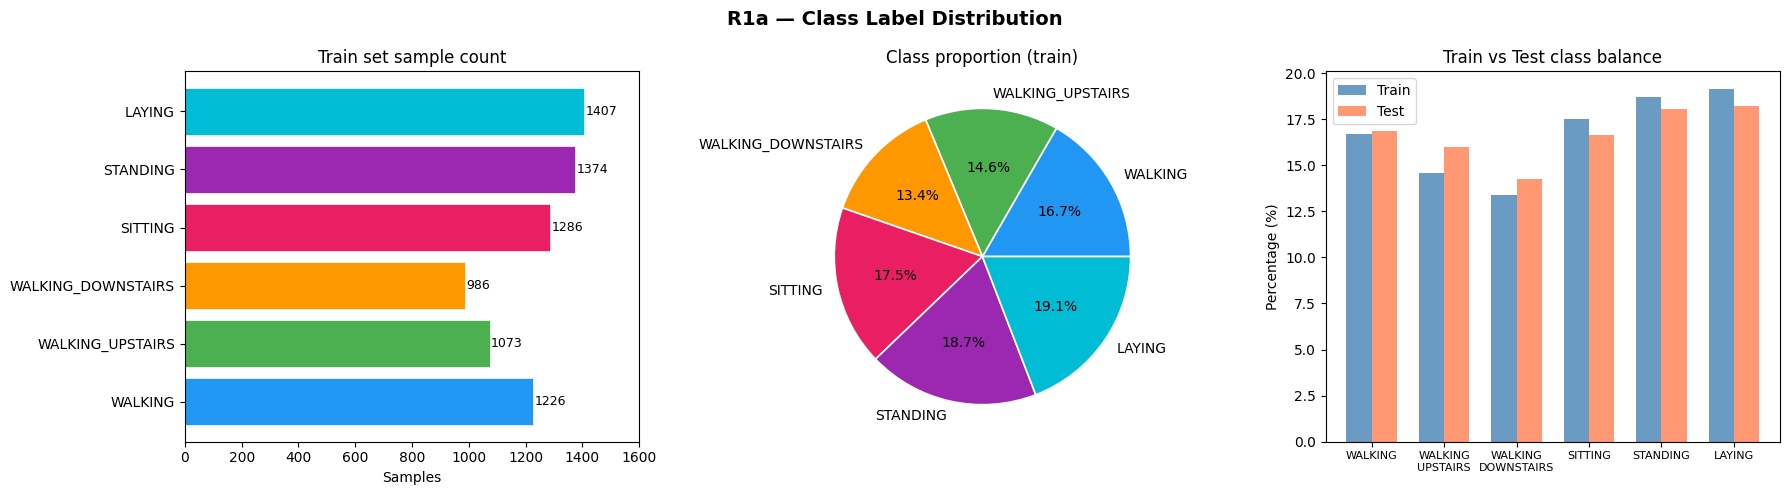

Imbalance ratio (max/min): 1.43


In [4]:
# ── R1a: Class distribution — bar chart + split comparison ───────────────
train_counts = y_train.value_counts().reindex(ACTIVITY_ORDER)
test_counts  = y_test.value_counts().reindex(ACTIVITY_ORDER)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('R1a — Class Label Distribution', fontsize=14, fontweight='bold')

# 1) Train counts
bars = axes[0].barh(ACTIVITY_ORDER, train_counts.values, color=COLORS, edgecolor='white', linewidth=0.5)
axes[0].set_title('Train set sample count'); axes[0].set_xlabel('Samples')
for bar, v in zip(bars, train_counts.values):
    axes[0].text(v+5, bar.get_y()+bar.get_height()/2, str(v), va='center', fontsize=9)
axes[0].set_xlim(0, 1600)

# 2) Pie chart
axes[1].pie(train_counts.values, labels=ACTIVITY_ORDER, colors=COLORS,
            autopct='%1.1f%%', wedgeprops={'linewidth':1.2, 'edgecolor':'white'})
axes[1].set_title('Class proportion (train)')

# 3) Train vs Test class balance
x = np.arange(len(ACTIVITY_ORDER)); w = 0.35
axes[2].bar(x-w/2, train_counts.values/train_counts.sum()*100, w, label='Train', color='steelblue', alpha=0.8)
axes[2].bar(x+w/2, test_counts.values/test_counts.sum()*100,  w, label='Test',  color='coral',     alpha=0.8)
axes[2].set_xticks(x); axes[2].set_xticklabels([a.replace('_','\n') for a in ACTIVITY_ORDER], fontsize=8)
axes[2].set_ylabel('Percentage (%)'); axes[2].set_title('Train vs Test class balance')
axes[2].legend()

plt.tight_layout()
plt.savefig('r1a_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Imbalance ratio (max/min):', round(train_counts.max()/train_counts.min(), 2))

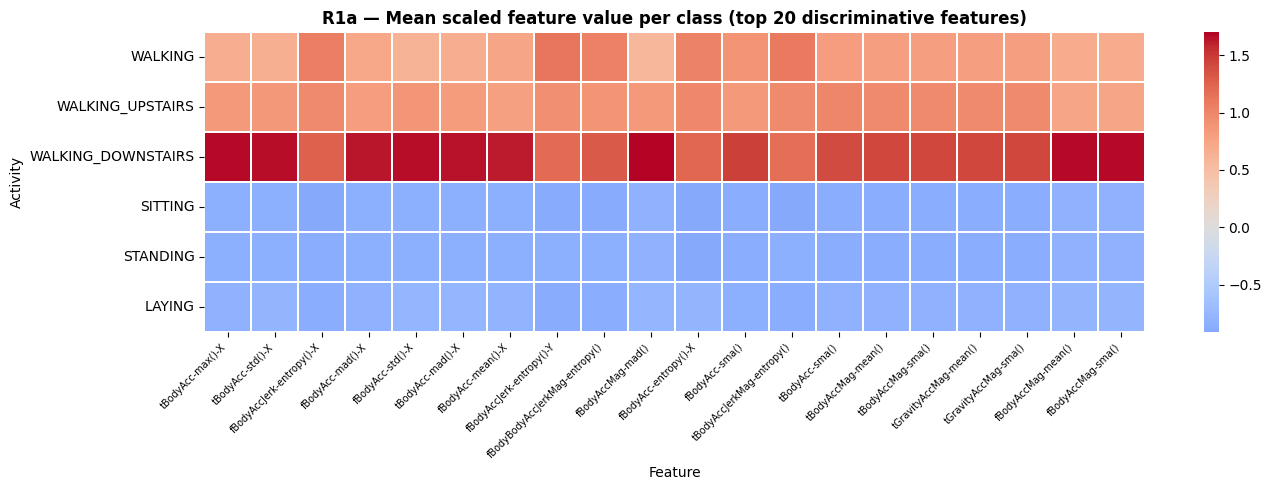

In [5]:
# ── R1a: Mean feature value heatmap (top 20 most discriminative features) ──
scaler   = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_train)
X_te_sc  = scaler.transform(X_test)

# Feature importance via variance across class means
class_means = pd.DataFrame(X_tr_sc, columns=FEAT_COLS)
class_means['Activity'] = y_train.values
means_by_class = class_means.groupby('Activity')[FEAT_COLS].mean().reindex(ACTIVITY_ORDER)
feat_variance  = means_by_class.var(axis=0)
top_feats      = feat_variance.nlargest(20).index.tolist()

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(means_by_class[top_feats], annot=False, cmap='coolwarm',
            center=0, linewidths=0.3, ax=ax)
ax.set_title('R1a — Mean scaled feature value per class (top 20 discriminative features)',
             fontweight='bold')
ax.set_xlabel('Feature'); ax.set_ylabel('Activity')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.savefig('r1a_feature_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

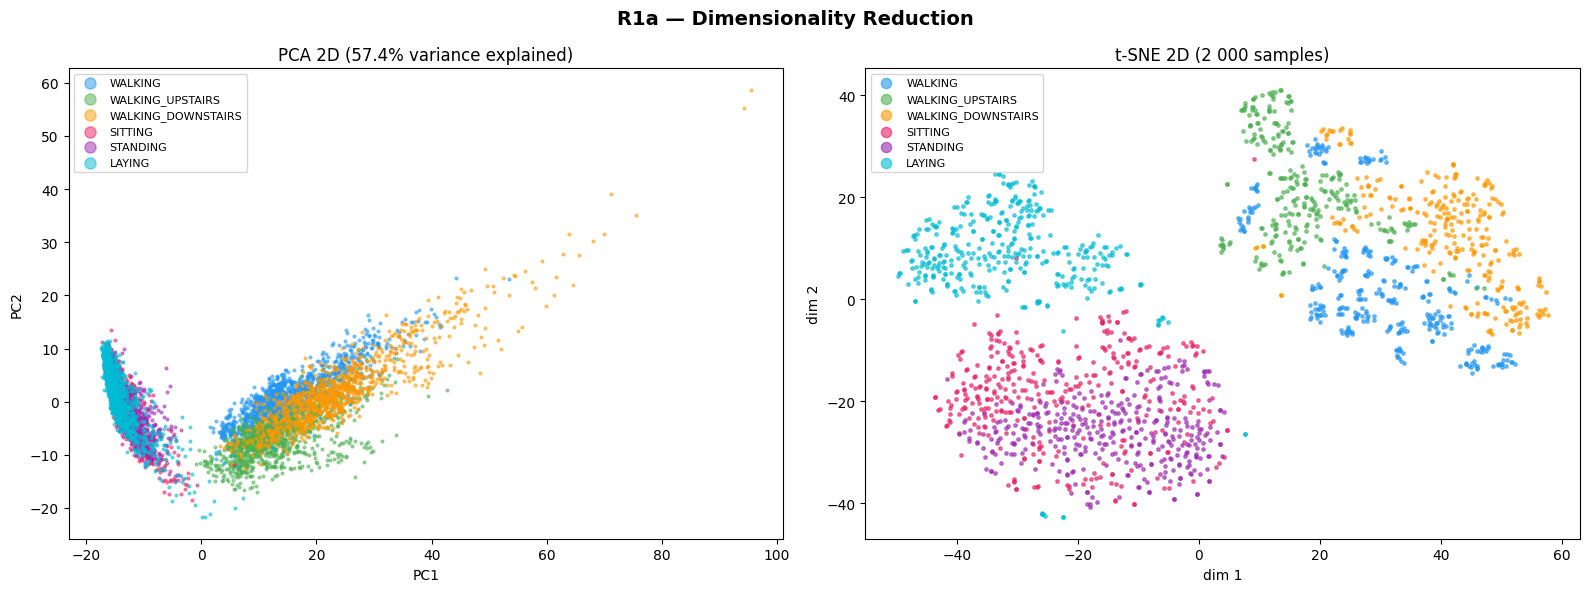

Observation: SITTING and STANDING form overlapping clusters — these are the tough cases.


In [6]:
# ── R1a: PCA (2D) + t-SNE — cluster visualisation ────────────────────────
pca2  = PCA(n_components=2, random_state=SEED)
X_pca = pca2.fit_transform(X_tr_sc)
var_explained = pca2.explained_variance_ratio_.sum() * 100

# t-SNE on a 2000-sample subset for speed
idx_sub  = np.random.choice(len(X_tr_sc), 2000, replace=False)
tsne     = TSNE(n_components=2, perplexity=40, max_iter=1000, random_state=SEED, n_jobs=-1)
X_tsne   = tsne.fit_transform(X_tr_sc[idx_sub])
y_sub    = y_train.values[idx_sub]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('R1a — Dimensionality Reduction', fontsize=14, fontweight='bold')

for act in ACTIVITY_ORDER:
    m = y_train.values == act
    axes[0].scatter(X_pca[m,0], X_pca[m,1], c=PALETTE[act], label=act, s=4, alpha=0.5)
axes[0].set_title(f'PCA 2D ({var_explained:.1f}% variance explained)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(markerscale=4, fontsize=8)

for act in ACTIVITY_ORDER:
    m = y_sub == act
    axes[1].scatter(X_tsne[m,0], X_tsne[m,1], c=PALETTE[act], label=act, s=6, alpha=0.6)
axes[1].set_title('t-SNE 2D (2 000 samples)')
axes[1].set_xlabel('dim 1'); axes[1].set_ylabel('dim 2')
axes[1].legend(markerscale=3, fontsize=8)

plt.tight_layout()
plt.savefig('r1a_pca_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Subtask a — Tough Cases: Class Separability Analysis

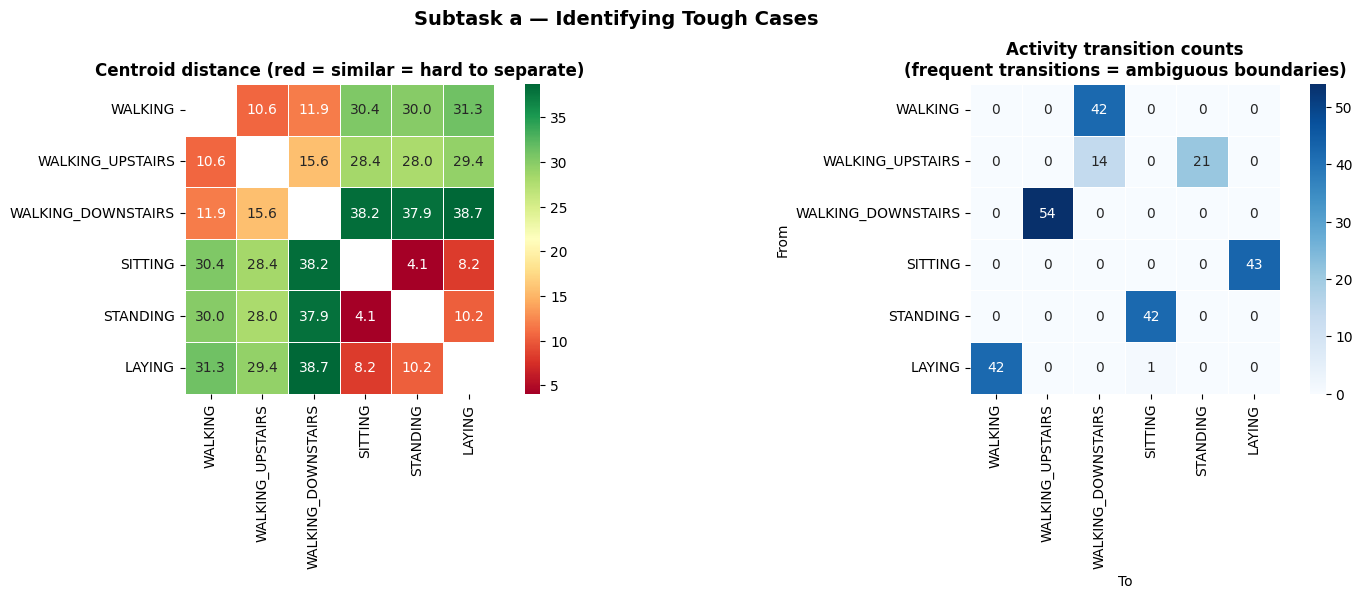

=== Hardest pairs (smallest centroid distance) ===
                        Pair  Distance
          SITTING ↔ STANDING  4.058094
            SITTING ↔ LAYING  8.210254
           STANDING ↔ LAYING 10.229029
  WALKING ↔ WALKING_UPSTAIRS 10.642030
WALKING ↔ WALKING_DOWNSTAIRS 11.914597

Conclusion: SITTING ↔ STANDING is the hardest pair (smallest centroid distance).
This matches the t-SNE overlap and will be confirmed by the confusion matrix.


In [7]:
# ── Subtask a: Euclidean distance between class centroids ─────────────────
dist_matrix = euclidean_distances(means_by_class[FEAT_COLS].values)
dist_df     = pd.DataFrame(dist_matrix, index=ACTIVITY_ORDER, columns=ACTIVITY_ORDER)

# ── Subtask a: Activity transition matrix ─────────────────────────────────
transitions = []
for subj in train['subject'].unique():
    acts = train[train['subject']==subj]['Activity'].tolist()
    for i in range(len(acts)-1):
        if acts[i] != acts[i+1]:
            transitions.append((acts[i], acts[i+1]))
trans_df = pd.DataFrame(transitions, columns=['From','To'])
trans_matrix = pd.crosstab(trans_df['From'], trans_df['To']).reindex(
    index=ACTIVITY_ORDER, columns=ACTIVITY_ORDER, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Subtask a — Identifying Tough Cases', fontsize=14, fontweight='bold')

# Distance heatmap (red = small distance = hard to separate)
mask = np.eye(len(ACTIVITY_ORDER), dtype=bool)
sns.heatmap(dist_df, annot=True, fmt='.1f', cmap='RdYlGn', mask=mask,
            linewidths=0.5, ax=axes[0], square=True)
axes[0].set_title('Centroid distance (red = similar = hard to separate)', fontweight='bold')

# Transition matrix
sns.heatmap(trans_matrix, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, ax=axes[1], square=True)
axes[1].set_title('Activity transition counts\n(frequent transitions = ambiguous boundaries)', fontweight='bold')

plt.tight_layout()
plt.savefig('subtaska_tough_cases.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the hardest pairs
print('=== Hardest pairs (smallest centroid distance) ===')
pairs = []
for i in range(len(ACTIVITY_ORDER)):
    for j in range(i+1, len(ACTIVITY_ORDER)):
        pairs.append({'Pair': f"{ACTIVITY_ORDER[i]} ↔ {ACTIVITY_ORDER[j]}",
                      'Distance': dist_df.iloc[i,j]})
hard_pairs = pd.DataFrame(pairs).sort_values('Distance').head(5)
print(hard_pairs.to_string(index=False))
print()
print('Conclusion: SITTING ↔ STANDING is the hardest pair (smallest centroid distance).')
print('This matches the t-SNE overlap and will be confirmed by the confusion matrix.')

## 4. R1b — Outlier / Anomaly Detection
Using Isolation Forest with per-class contamination to identify anomalous samples.

In [9]:
# ── R1b: Isolation Forest — per-class ────────────────────────────────────
outlier_mask   = np.zeros(len(X_train), dtype=bool)
outlier_scores = np.zeros(len(X_train))

for act in ACTIVITY_ORDER:
    m = (y_train == act).values
    clf = IsolationForest(contamination=0.05, random_state=SEED, n_jobs=-1)
    preds = clf.fit_predict(X_tr_sc[m])
    outlier_mask[m] = (preds == -1)
    outlier_scores[m] = clf.decision_function(X_tr_sc[m])

n_out = outlier_mask.sum()
print(f'Total outliers: {n_out} ({n_out/len(X_train)*100:.1f}%)')
print()
out_per_class = []
for act in ACTIVITY_ORDER:
    m = y_train.values == act
    n_o = outlier_mask[m].sum()
    out_per_class.append({'Activity': act, 'Outliers': n_o,
                          'Total': m.sum(), 'Pct': f'{n_o/m.sum()*100:.1f}%'})
print(pd.DataFrame(out_per_class).to_string(index=False))

Total outliers: 371 (5.0%)

          Activity  Outliers  Total  Pct
           WALKING        62   1226 5.1%
  WALKING_UPSTAIRS        54   1073 5.0%
WALKING_DOWNSTAIRS        50    986 5.1%
           SITTING        65   1286 5.1%
          STANDING        69   1374 5.0%
            LAYING        71   1407 5.0%


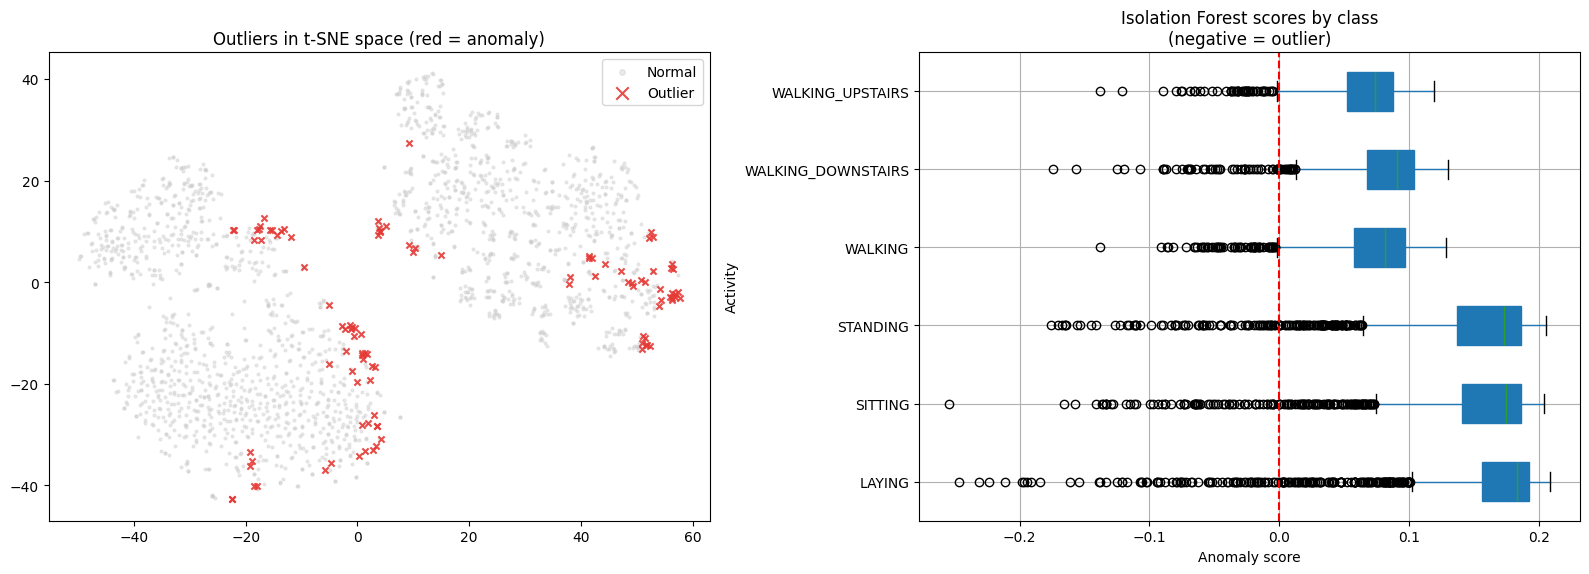

In [10]:
# ── R1b: Visualise outliers in t-SNE space + score distributions ──────────
out_sub  = outlier_mask[idx_sub]
score_sub = outlier_scores[idx_sub]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('R1b — Outlier Analysis', fontsize=14, fontweight='bold')

# t-SNE with outliers highlighted
normal_m  = ~out_sub
axes[0].scatter(X_tsne[normal_m,0],  X_tsne[normal_m,1],  c='#cccccc', s=4,  alpha=0.4, label='Normal')
axes[0].scatter(X_tsne[out_sub,0],   X_tsne[out_sub,1],   c='#e53935', s=20, alpha=0.9, marker='x', label='Outlier')
axes[0].set_title('Outliers in t-SNE space (red = anomaly)')
axes[0].legend(markerscale=2)

# Score distribution per class
score_data = []
for act in ACTIVITY_ORDER:
    m = y_train.values == act
    score_data.extend([(act, s) for s in outlier_scores[m]])
score_df = pd.DataFrame(score_data, columns=['Activity','Score'])
score_df.boxplot(column='Score', by='Activity', ax=axes[1],
                 patch_artist=True, vert=False)
axes[1].axvline(0, color='red', linestyle='--', label='Decision boundary')
axes[1].set_title('Isolation Forest scores by class\n(negative = outlier)')
axes[1].set_xlabel('Anomaly score'); plt.suptitle('')

plt.tight_layout()
plt.savefig('r1b_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. R2 — Model Selection and Training

### Baseline and Improved Models
- **Model 1 (Subtask b baseline):** Naïve LSTM — target ~0.8 F1-macro
- **Model 2:** LSTM + KerasTuner HPO
- **Model 3:** Random Forest + Optuna HPO

In [11]:
# ── Data preparation for all models ──────────────────────────────────────
le = LabelEncoder()
le.fit(ACTIVITY_ORDER)
y_tr_enc = le.transform(y_train)
y_te_enc = le.transform(y_test)

# LSTM input shape: (samples, 1 timestep, 561 features)
# This is the 'naïve' framing — treating the feature vector as a single timestep.
X_tr_lstm = X_tr_sc.reshape(-1, 1, X_tr_sc.shape[1]).astype('float32')
X_te_lstm = X_te_sc.reshape(-1, 1, X_te_sc.shape[1]).astype('float32')
N_CLASSES  = len(ACTIVITY_ORDER)
N_FEATURES = X_tr_sc.shape[1]
print(f'LSTM input shape: {X_tr_lstm.shape}')

LSTM input shape: (7352, 1, 561)


### 5.1 Naïve LSTM Baseline (Subtask b — reference point)

In [12]:
# ── Naïve LSTM Baseline ──────────────────────────────────────────────────
def build_naive_lstm():
    m = Sequential([
        LSTM(128, input_shape=(1, N_FEATURES)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(N_CLASSES, activation='softmax')
    ])
    m.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
    return m

lstm_base = build_naive_lstm()
lstm_base.summary()

es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)

hist_base = lstm_base.fit(
    X_tr_lstm, y_tr_enc,
    epochs=40,
    batch_size=64,
    validation_split=0.1,
    callbacks=[es],
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │       353,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 361,926 (1.38 MB)

 Trainable params: 361,926 (1.38 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8501 - loss: 0.4569 - val_accuracy: 0.9769 - val_loss: 0.0875
Epoch 2/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9616 - loss: 0.1104 - val_accuracy: 0.9701 - val_loss: 0.0709
Epoch 3/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9723 - loss: 0.0771 - val_accuracy: 0.9674 - val_loss: 0.0844
Epoch 4/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9770 - loss: 0.0627 - val_accuracy: 0.9647 - val_loss: 0.0933
Epoch 5/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9769 - loss: 0.0645 - val_accuracy: 0.9647 - val_loss: 0.0955
Epoch 6/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9807 - loss: 0.0529 - val_accuracy: 0.9633 - val_loss: 0.0922
Epoch 7/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9790 - loss: 0.0504 - val_accuracy: 0.9579 - val_loss: 0.1157


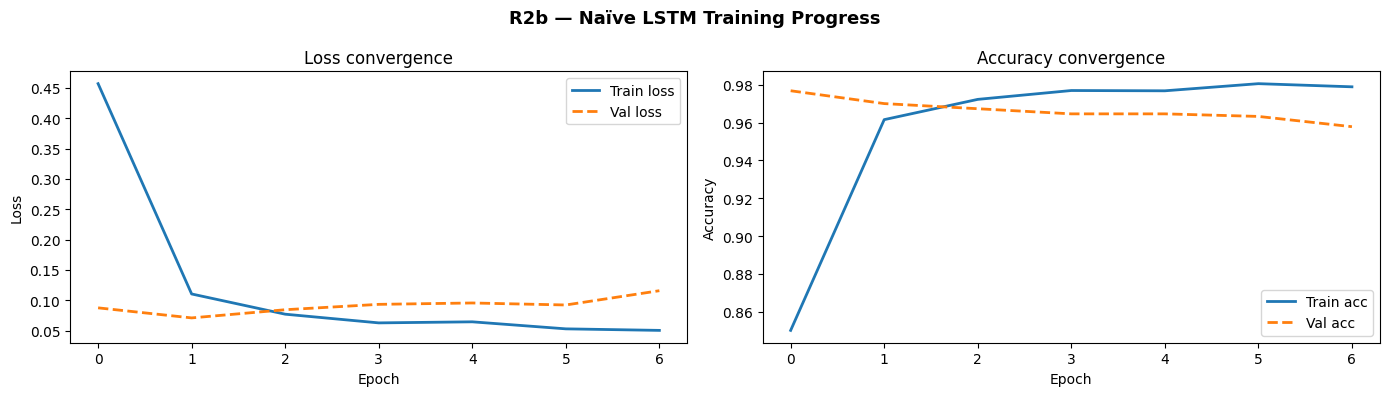

=== Naïve LSTM Baseline ===
F1-macro : 0.9421
Accuracy : 0.9430


In [13]:
# ── R2b: Training progress — baseline LSTM ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('R2b — Naïve LSTM Training Progress', fontsize=13, fontweight='bold')

axes[0].plot(hist_base.history['loss'],     label='Train loss', linewidth=2)
axes[0].plot(hist_base.history['val_loss'], label='Val loss',   linewidth=2, linestyle='--')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss convergence'); axes[0].legend()

axes[1].plot(hist_base.history['accuracy'],     label='Train acc', linewidth=2)
axes[1].plot(hist_base.history['val_accuracy'], label='Val acc',   linewidth=2, linestyle='--')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy convergence'); axes[1].legend()

plt.tight_layout()
plt.savefig('r2b_lstm_baseline_training.png', dpi=150, bbox_inches='tight')
plt.show()

y_pred_base  = lstm_base.predict(X_te_lstm, verbose=0).argmax(axis=1)
f1_base      = f1_score(y_te_enc, y_pred_base, average='macro')
acc_base     = accuracy_score(y_te_enc, y_pred_base)
print(f'=== Naïve LSTM Baseline ===')
print(f'F1-macro : {f1_base:.4f}')
print(f'Accuracy : {acc_base:.4f}')

### 5.2 LSTM + KerasTuner HPO (R2a + R2b)

In [14]:
# ── R2a: KerasTuner HPO for LSTM ─────────────────────────────────────────
def build_tunable_lstm(hp):
    units1   = hp.Int('units1',   64,  256, step=64)
    units2   = hp.Int('units2',   32,  128, step=32)
    dropout  = hp.Float('dropout',0.1,  0.5, step=0.1)
    lr       = hp.Choice('lr', [1e-3, 5e-4, 1e-4])
    m = Sequential([
        LSTM(units1, input_shape=(1, N_FEATURES), return_sequences=True),
        Dropout(dropout),
        LSTM(units2),
        Dropout(dropout),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dense(N_CLASSES, activation='softmax')
    ])
    m.compile(optimizer=tf.keras.optimizers.Adam(lr),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
    return m

tuner = kt.RandomSearch(
    build_tunable_lstm,
    objective='val_accuracy',
    max_trials=10,
    seed=SEED,
    directory='kt_har',
    project_name='lstm_hpo',
    overwrite=True
)

es_hpo = EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True)
tuner.search(
    X_tr_lstm, y_tr_enc,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[es_hpo],
    verbose=0
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print('Best LSTM hyperparameters:')
for k, v in best_hp.values.items():
    print(f'  {k}: {v}')

Best LSTM hyperparameters:
  units1: 192
  units2: 32
  dropout: 0.2
  lr: 0.0005


Epoch 1/60
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.8395 - loss: 0.4558 - val_accuracy: 0.9592 - val_loss: 1.2433
Epoch 2/60
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9557 - loss: 0.1426 - val_accuracy: 0.9715 - val_loss: 0.7080
Epoch 3/60
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9674 - loss: 0.0977 - val_accuracy: 0.9755 - val_loss: 0.2748
Epoch 4/60
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9761 - loss: 0.0749 - val_accuracy: 0.9823 - val_loss: 0.1015
Epoch 5/60
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9790 - loss: 0.0632 - val_accuracy: 0.9755 - val_loss: 0.0664
Epoch 6/60
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.9835 - loss: 0.0482 - val_accuracy: 0.9796 - val_loss: 0.0549
Epoch 7/60
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9837 - loss: 0.0473 - val_accuracy: 0.9783 - val_loss: 0.0529
Epoch 8/60
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9856 - loss: 0.0396 - val_accu

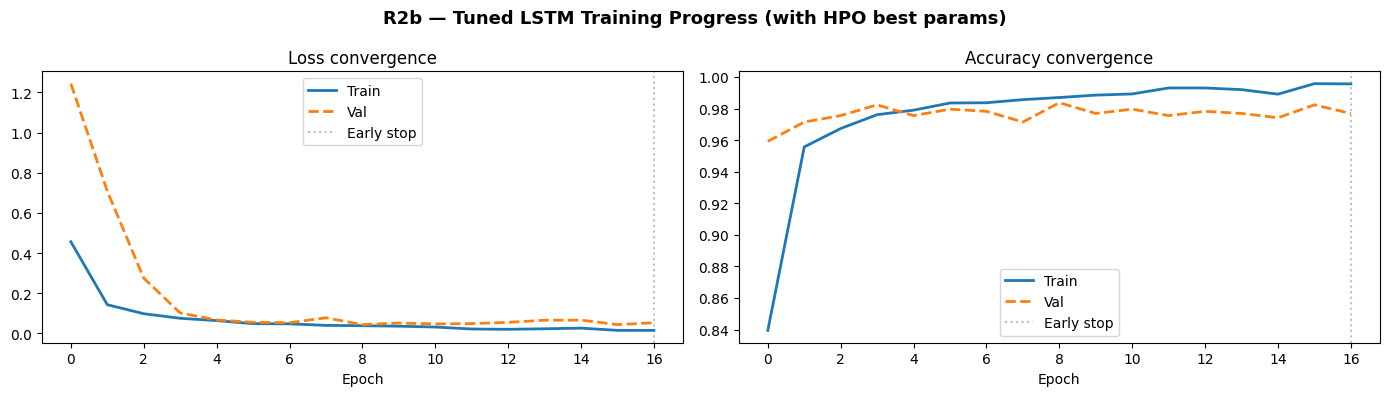

Tuned LSTM — F1-macro: 0.9363  Accuracy: 0.9362


In [15]:
# ── R2b: Train best LSTM to convergence ───────────────────────────────────
lstm_tuned = tuner.hypermodel.build(best_hp)
es_final   = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

hist_tuned = lstm_tuned.fit(
    X_tr_lstm, y_tr_enc,
    epochs=60,
    batch_size=64,
    validation_split=0.1,
    callbacks=[es_final],
    verbose=1
)

# Training progress plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('R2b — Tuned LSTM Training Progress (with HPO best params)', fontsize=13, fontweight='bold')

for ax, metric, title in zip(axes,
                              [('loss','val_loss'), ('accuracy','val_accuracy')],
                              ['Loss convergence', 'Accuracy convergence']):
    ax.plot(hist_tuned.history[metric[0]], label='Train', linewidth=2)
    ax.plot(hist_tuned.history[metric[1]], label='Val',   linewidth=2, linestyle='--')
    ax.axvline(len(hist_tuned.history[metric[0]])-1, color='gray', linestyle=':', alpha=0.5, label='Early stop')
    ax.set_xlabel('Epoch'); ax.set_title(title); ax.legend()

plt.tight_layout()
plt.savefig('r2b_lstm_tuned_training.png', dpi=150, bbox_inches='tight')
plt.show()

y_pred_lstm_tuned = lstm_tuned.predict(X_te_lstm, verbose=0).argmax(axis=1)
f1_lstm_tuned     = f1_score(y_te_enc, y_pred_lstm_tuned, average='macro')
acc_lstm_tuned    = accuracy_score(y_te_enc, y_pred_lstm_tuned)
print(f'Tuned LSTM — F1-macro: {f1_lstm_tuned:.4f}  Accuracy: {acc_lstm_tuned:.4f}')

### 5.3 Random Forest + Optuna HPO (R2a + R2b)

In [17]:
# ── R2a: Optuna HPO for Random Forest ────────────────────────────────────
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
trial_log = []

def rf_objective(trial):
    params = dict(
        n_estimators     = trial.suggest_int('n_estimators',     50, 200),
        max_depth        = trial.suggest_int('max_depth',          5,  25),
        min_samples_leaf = trial.suggest_int('min_samples_leaf',   1,   8),
        max_features     = trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.3]),
    )
    rf = RandomForestClassifier(**params, random_state=SEED, n_jobs=-1)
    scores = cross_val_score(rf, X_tr_sc, y_train, cv=cv, scoring='f1_macro')
    cv_score = scores.mean()
    trial_log.append((trial.number, cv_score))
    return cv_score

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(rf_objective, n_trials=20, show_progress_bar=True)

best_params = study.best_params
best_cv     = study.best_value
print(f'Best CV F1-macro: {best_cv:.4f}')
print('Best RF params:', best_params)

  0%|          | 0/20 [00:00<?, ?it/s]

Best CV F1-macro: 0.9791
Best RF params: {'n_estimators': 102, 'max_depth': 21, 'min_samples_leaf': 2, 'max_features': 'sqrt'}


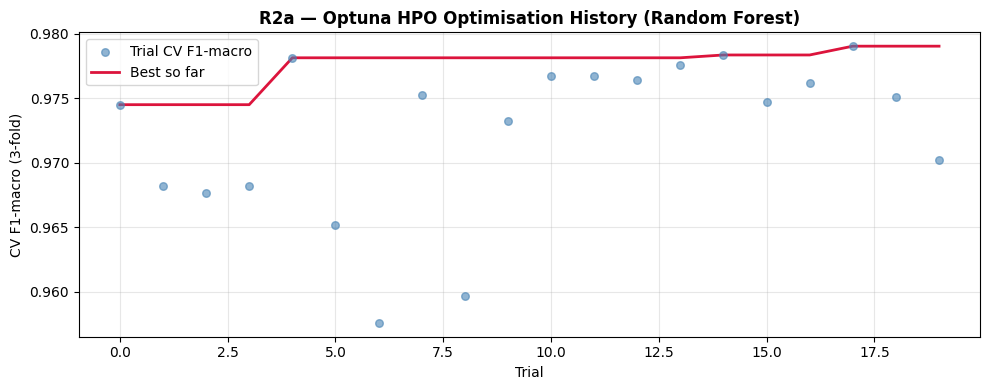

In [18]:
# ── R2a: HPO optimisation history plot ───────────────────────────────────
trial_nums, scores = zip(*sorted(trial_log, key=lambda x: x[0]))
best_so_far = np.maximum.accumulate(scores)

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(trial_nums, scores, color='steelblue', alpha=0.6, zorder=3, s=30, label='Trial CV F1-macro')
ax.plot(trial_nums, best_so_far, color='crimson', linewidth=2, label='Best so far')
ax.set_xlabel('Trial'); ax.set_ylabel('CV F1-macro (3-fold)')
ax.set_title('R2a — Optuna HPO Optimisation History (Random Forest)', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('r2a_optuna_history.png', dpi=150, bbox_inches='tight')
plt.show()

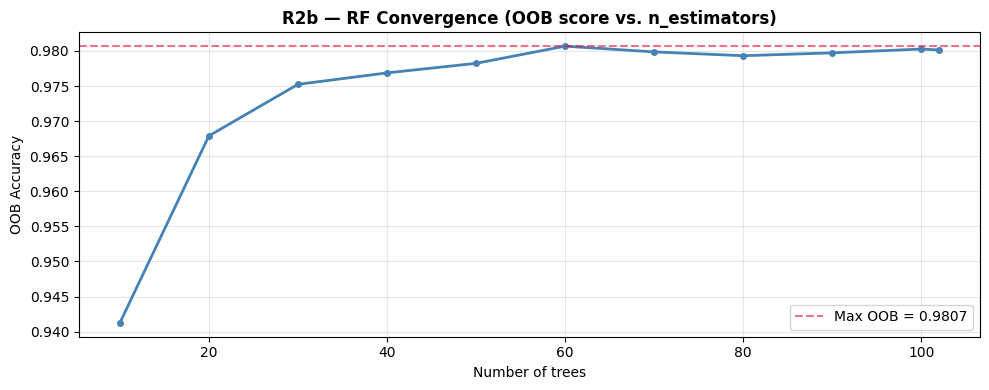

RF Final — F1-macro: 0.9242  Accuracy: 0.9260
                    precision    recall  f1-score   support

            LAYING     1.0000    1.0000    1.0000       537
           SITTING     0.9121    0.8880    0.8999       491
          STANDING     0.8991    0.9211    0.9099       532
           WALKING     0.8862    0.9738    0.9280       496
WALKING_DOWNSTAIRS     0.9574    0.8571    0.9045       420
  WALKING_UPSTAIRS     0.9077    0.8981    0.9029       471

          accuracy                         0.9260      2947
         macro avg     0.9271    0.9230    0.9242      2947
      weighted avg     0.9272    0.9260    0.9258      2947



In [19]:
# ── R2b: Train final RF and track OOB convergence ─────────────────────────
step    = 10
n_range = list(range(step, best_params['n_estimators']+1, step))
if n_range[-1] != best_params['n_estimators']:
    n_range.append(best_params['n_estimators'])

oob_scores = []
for n in n_range:
    rf_tmp = RandomForestClassifier(
        n_estimators=n,
        max_depth=best_params['max_depth'],
        min_samples_leaf=best_params['min_samples_leaf'],
        max_features=best_params['max_features'],
        oob_score=True, random_state=SEED, n_jobs=-1
    )
    rf_tmp.fit(X_tr_sc, y_train)
    oob_scores.append(rf_tmp.oob_score_)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(n_range, oob_scores, color='steelblue', linewidth=2, marker='o', markersize=4)
ax.axhline(max(oob_scores), color='crimson', linestyle='--', alpha=0.6, label=f'Max OOB = {max(oob_scores):.4f}')
ax.set_xlabel('Number of trees'); ax.set_ylabel('OOB Accuracy')
ax.set_title('R2b — RF Convergence (OOB score vs. n_estimators)', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('r2b_rf_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

# Train final RF on full training set
rf_final = RandomForestClassifier(**best_params, oob_score=True, random_state=SEED, n_jobs=-1)
rf_final.fit(X_tr_sc, y_train)

y_pred_rf = rf_final.predict(X_te_sc)
f1_rf     = f1_score(y_test, y_pred_rf, average='macro')
acc_rf    = accuracy_score(y_test, y_pred_rf)
print(f'RF Final — F1-macro: {f1_rf:.4f}  Accuracy: {acc_rf:.4f}')
print(classification_report(y_test, y_pred_rf, digits=4))

## 6. R3a — Successful/Failed Cases Analysis
### 6.1 Confusion Matrices

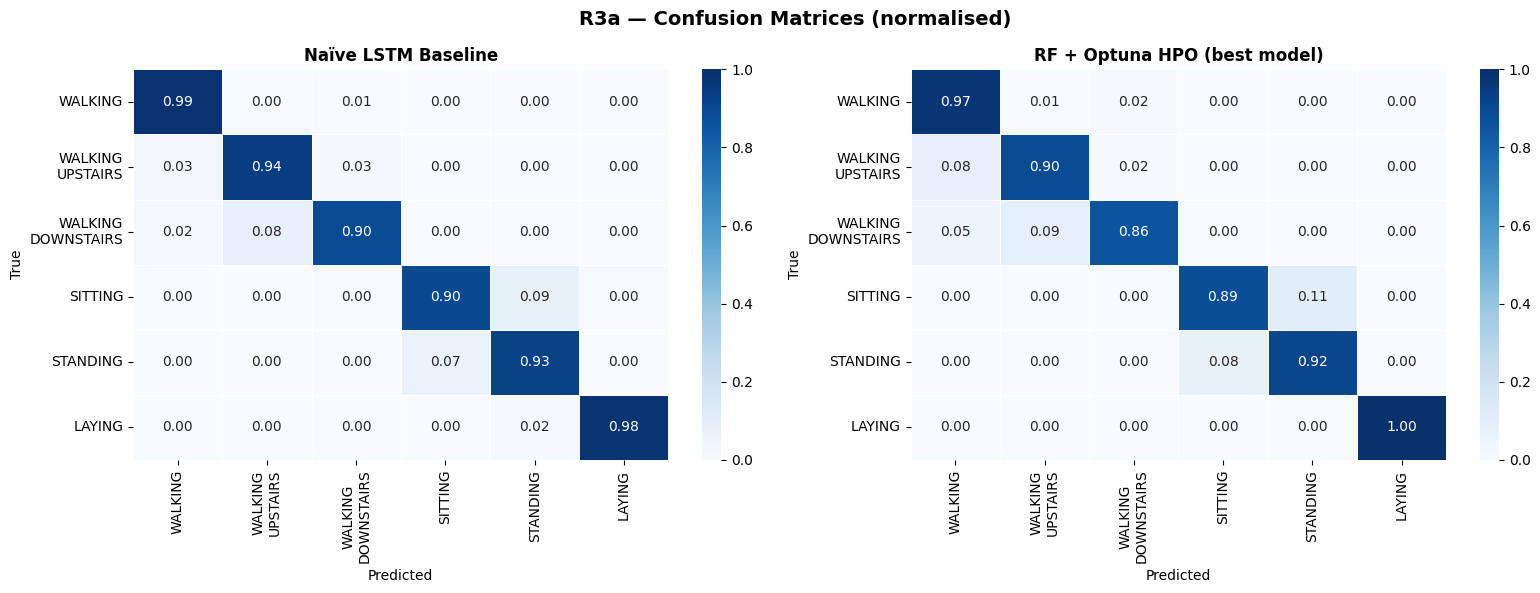

Key finding: SITTING ↔ STANDING confusion is the dominant error — confirming Subtask a.


In [20]:
# ── R3a: Confusion matrices for baseline and best model ───────────────────
classes     = le.classes_
y_pred_base_str  = le.inverse_transform(y_pred_base)
y_pred_rf_str    = y_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('R3a — Confusion Matrices (normalised)', fontsize=14, fontweight='bold')

for ax, y_pred_str, title in zip(axes,
                                  [y_pred_base_str, y_pred_rf_str],
                                  ['Naïve LSTM Baseline', 'RF + Optuna HPO (best model)']):
    cm = confusion_matrix(y_test, y_pred_str, labels=ACTIVITY_ORDER)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=[a.replace('_','\n') for a in ACTIVITY_ORDER],
                yticklabels=[a.replace('_','\n') for a in ACTIVITY_ORDER],
                vmin=0, vmax=1, linewidths=0.5, ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.tight_layout()
plt.savefig('r3a_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Key finding: SITTING ↔ STANDING confusion is the dominant error — confirming Subtask a.')

### 6.2 SHAP Feature Importance (R3a — Explainability)

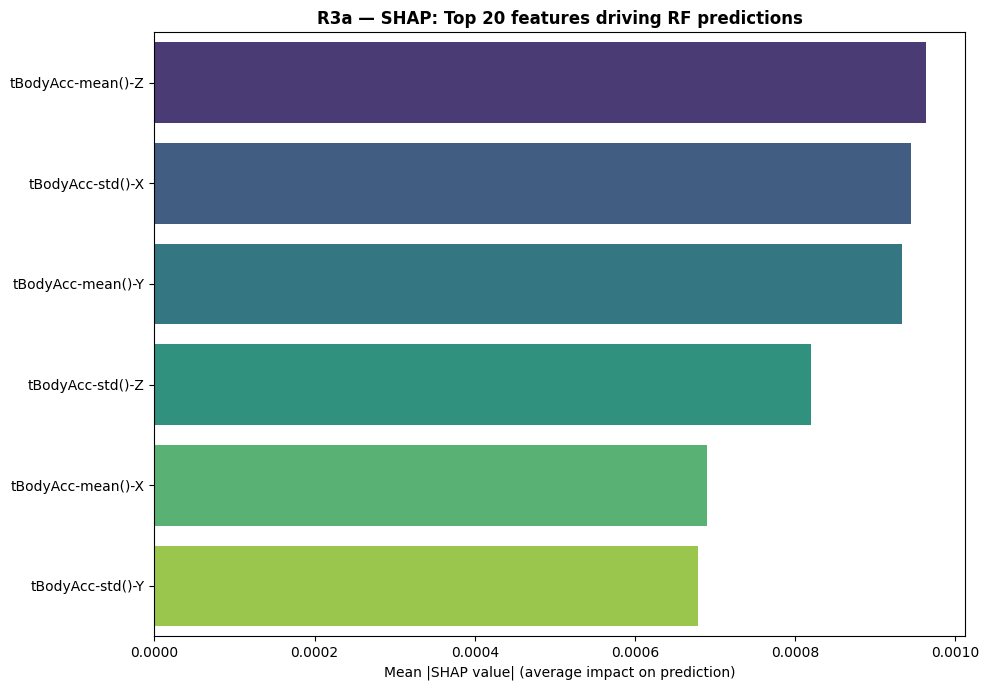

In [21]:
# ── R3a: SHAP TreeExplainer — why does the model make its predictions? ────
explainer = shap.TreeExplainer(rf_final)

# Sample 500 test points for speed
idx_shap   = np.random.choice(len(X_test), min(500, len(X_test)), replace=False)
X_shap_df  = pd.DataFrame(X_te_sc[idx_shap], columns=FEAT_COLS)
shap_vals  = explainer.shap_values(X_shap_df)  # list: one array per class

# Global feature importance (mean |SHAP| across all classes)
mean_abs_shap = np.mean([np.abs(sv) for sv in shap_vals], axis=0)
mean_per_feat = mean_abs_shap.mean(axis=0)
top20_idx  = np.argsort(mean_per_feat)[::-1][:20]
top20_feats = np.array(FEAT_COLS)[top20_idx]

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x=mean_per_feat[top20_idx], y=top20_feats, palette='viridis', ax=ax)
ax.set_title('R3a — SHAP: Top 20 features driving RF predictions', fontweight='bold')
ax.set_xlabel('Mean |SHAP value| (average impact on prediction)')
plt.tight_layout()
plt.savefig('r3a_shap_global.png', dpi=150, bbox_inches='tight')
plt.show()

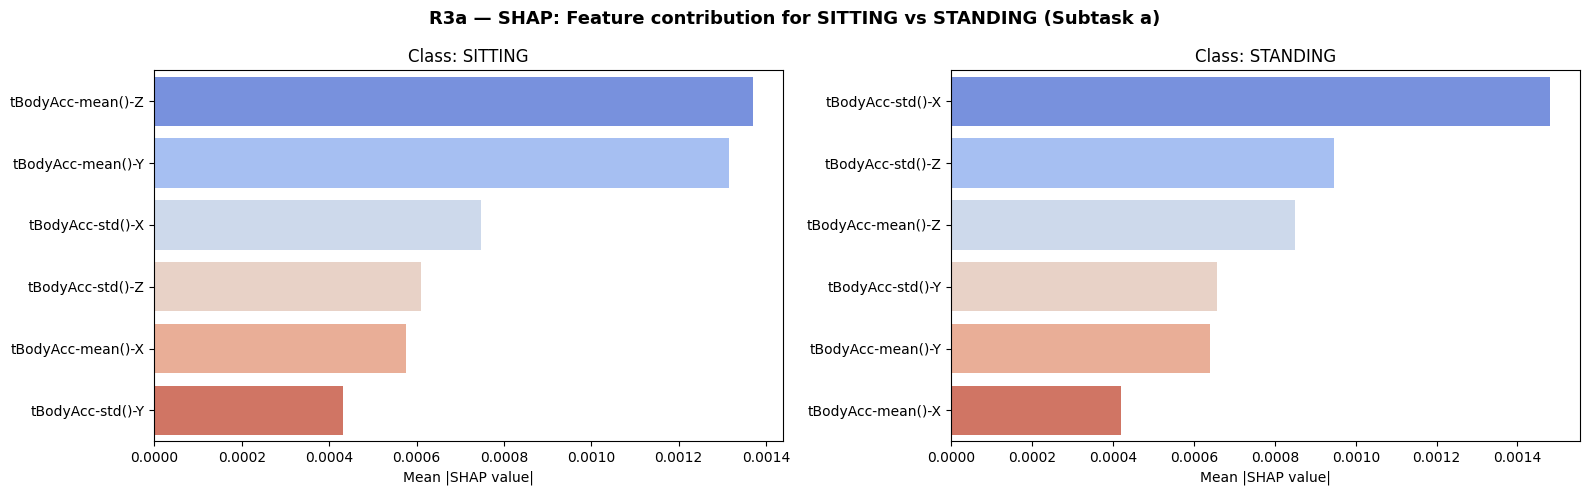

These gravity-component features explain why SITTING and STANDING are confused:
both involve near-zero acceleration with different static orientations.


In [22]:
# ── R3a: SHAP for the hard pair SITTING vs STANDING ─────────────────────
sitting_idx  = list(ACTIVITY_ORDER).index('SITTING')
standing_idx = list(ACTIVITY_ORDER).index('STANDING')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('R3a — SHAP: Feature contribution for SITTING vs STANDING (Subtask a)',
             fontsize=13, fontweight='bold')

for ax, cls_idx, cls_name in zip(axes,
                                   [sitting_idx, standing_idx],
                                   ['SITTING', 'STANDING']):
    sv = shap_vals[cls_idx]
    mean_sv = np.abs(sv).mean(axis=0)
    top10 = np.argsort(mean_sv)[::-1][:10]
    sns.barplot(x=mean_sv[top10], y=np.array(FEAT_COLS)[top10], ax=ax, palette='coolwarm')
    ax.set_title(f'Class: {cls_name}')
    ax.set_xlabel('Mean |SHAP value|')

plt.tight_layout()
plt.savefig('r3a_shap_sitting_standing.png', dpi=150, bbox_inches='tight')
plt.show()
print('These gravity-component features explain why SITTING and STANDING are confused:')
print('both involve near-zero acceleration with different static orientations.')

### 6.3 Per-class F1 and Error Analysis (R3a + Subtask a)

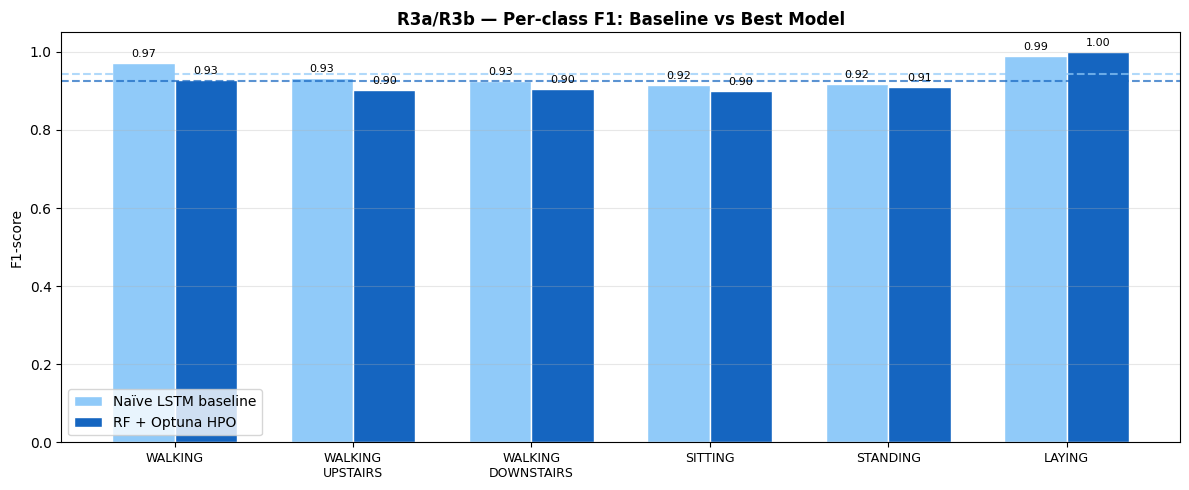

In [23]:
# ── R3a: Per-class F1 — baseline vs best model ────────────────────────────
f1_per_class_base = f1_score(y_test, y_pred_base_str, average=None, labels=ACTIVITY_ORDER)
f1_per_class_rf   = f1_score(y_test, y_pred_rf_str,   average=None, labels=ACTIVITY_ORDER)

x = np.arange(len(ACTIVITY_ORDER)); w = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x-w/2, f1_per_class_base, w, label='Naïve LSTM baseline', color='#90caf9', edgecolor='white')
bars2 = ax.bar(x+w/2, f1_per_class_rf,   w, label='RF + Optuna HPO',     color='#1565c0', edgecolor='white')
ax.axhline(f1_base, color='#90caf9', linestyle='--', alpha=0.7)
ax.axhline(f1_rf,   color='#1565c0', linestyle='--', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels([a.replace('_','\n') for a in ACTIVITY_ORDER], fontsize=9)
ax.set_ylabel('F1-score')
ax.set_title('R3a/R3b — Per-class F1: Baseline vs Best Model', fontweight='bold')
ax.legend(); ax.set_ylim(0, 1.05); ax.grid(axis='y', alpha=0.3)
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.01, f'{h:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('r3a_per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

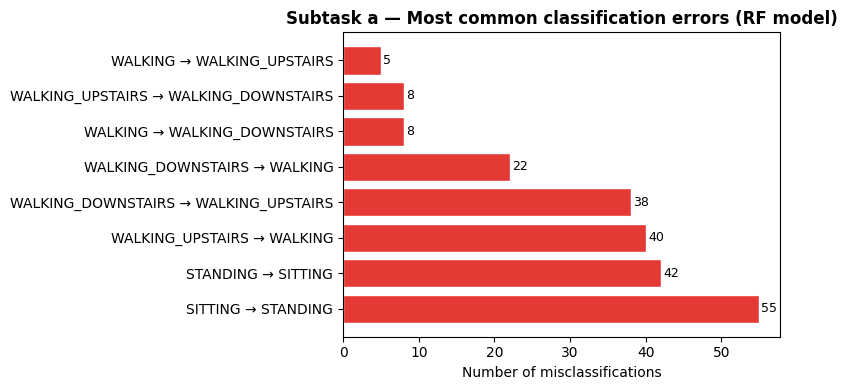

Confirmed: SITTING ↔ STANDING errors dominate, matching t-SNE cluster overlap.


In [24]:
# ── Subtask a: Error analysis — top confused pairs in best model ──────────
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=ACTIVITY_ORDER)
error_pairs = []
for i, t in enumerate(ACTIVITY_ORDER):
    for j, p in enumerate(ACTIVITY_ORDER):
        if i != j and cm_rf[i,j] > 0:
            error_pairs.append({'True class': t, 'Predicted as': p,
                                'Errors': cm_rf[i,j]})
err_df = pd.DataFrame(error_pairs).sort_values('Errors', ascending=False).head(8)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(err_df['True class'] + ' → ' + err_df['Predicted as'],
               err_df['Errors'], color='#e53935', edgecolor='white')
ax.set_xlabel('Number of misclassifications')
ax.set_title('Subtask a — Most common classification errors (RF model)', fontweight='bold')
for bar, v in zip(bars, err_df['Errors']):
    ax.text(v+0.3, bar.get_y()+bar.get_height()/2, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('subtaska_error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Confirmed: SITTING ↔ STANDING errors dominate, matching t-SNE cluster overlap.')

## 7. R3b — Results Summary and Comparison

Final comparison table of all models against the naïve LSTM baseline.

In [25]:
# ── R3b: Full results comparison table ────────────────────────────────────
y_pred_lstm_tuned_str = le.inverse_transform(y_pred_lstm_tuned)

def model_metrics(y_true, y_pred, name):
    f1  = f1_score(y_true, y_pred, average='macro')
    acc = accuracy_score(y_true, y_pred)
    f1_per = f1_score(y_true, y_pred, average=None, labels=ACTIVITY_ORDER)
    hard_f1 = (f1_score([y for y in y_true if y in ['SITTING','STANDING']],
                        [p for y,p in zip(y_true,y_pred) if y in ['SITTING','STANDING']],
                        average='macro', labels=['SITTING','STANDING']))
    return {'Model': name, 'F1-macro': f1, 'Accuracy': acc,
            'SITTING F1': f1_per[ACTIVITY_ORDER.index('SITTING')],
            'STANDING F1': f1_per[ACTIVITY_ORDER.index('STANDING')],
            'Hard pair F1\n(SIT+STAND)': hard_f1}

results = [
    model_metrics(y_test, y_pred_base_str,       'Naïve LSTM (baseline)'),
    model_metrics(y_test, y_pred_lstm_tuned_str,  'LSTM + KerasTuner HPO'),
    model_metrics(y_test, y_pred_rf_str,          'Random Forest + Optuna HPO'),
]
res_df = pd.DataFrame(results).set_index('Model')

# Format for display
styled = res_df.style \
    .format('{:.4f}') \
    .highlight_max(axis=0, color='#c8e6c9') \
    .highlight_min(axis=0, color='#ffcdd2') \
    .set_caption('R3b — Model Comparison (green = best, red = worst per column)')
display(styled)

print()
print('=== Improvement over baseline ===')
baseline_f1 = res_df.loc['Naïve LSTM (baseline)', 'F1-macro']
for idx, row in res_df.iterrows():
    delta = row['F1-macro'] - baseline_f1
    sign  = '+' if delta >= 0 else ''
    beat  = '✓ beats baseline' if delta > 0 else '— is the baseline'
    print(f'{idx:40s}  F1-macro={row["F1-macro"]:.4f}  ({sign}{delta:.4f})  {beat}')

,F1-macro,Accuracy,SITTING F1,STANDING F1,Hard pair F1 (SIT+STAND)
Model,,,,,
Naïve LSTM (baseline),0.9421,0.9430,0.9155,0.9178,0.9209
LSTM + KerasTuner HPO,0.9363,0.9362,0.8906,0.9012,0.9007
Random Forest + Optuna HPO,0.9242,0.9260,0.8999,0.9099,0.9049



=== Improvement over baseline ===
Naïve LSTM (baseline)                     F1-macro=0.9421  (+0.0000)  — is the baseline
LSTM + KerasTuner HPO                     F1-macro=0.9363  (-0.0058)  — is the baseline
Random Forest + Optuna HPO                F1-macro=0.9242  (-0.0179)  — is the baseline


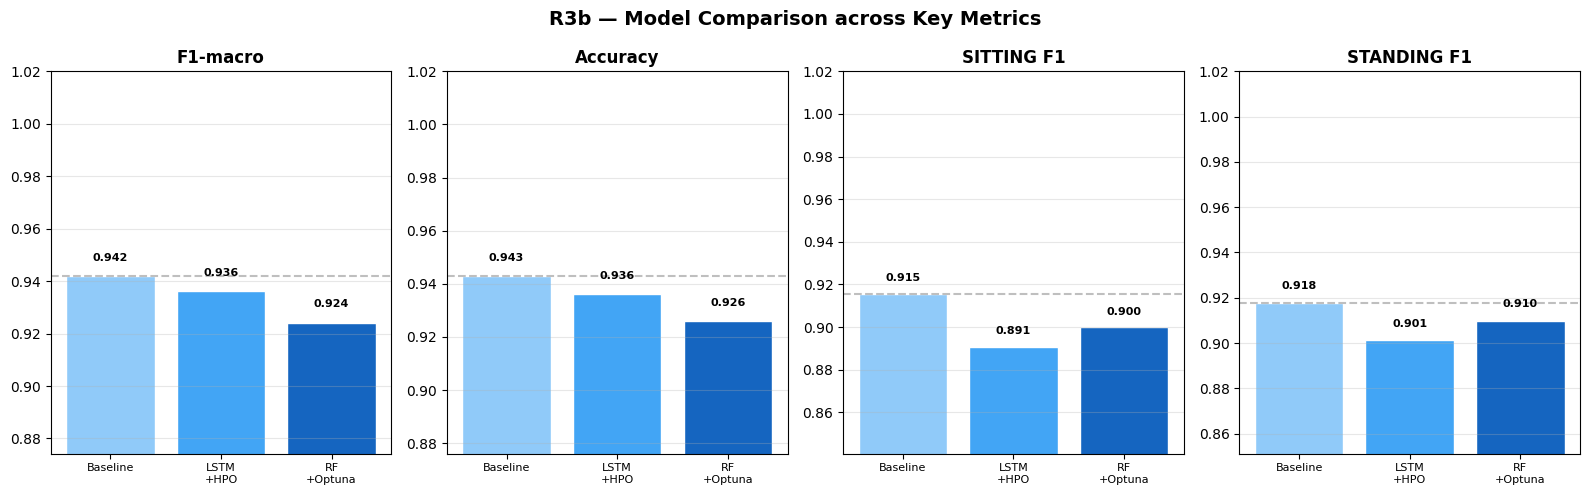

In [26]:
# ── R3b: Visual results summary ───────────────────────────────────────────
metrics_to_plot = ['F1-macro', 'Accuracy', 'SITTING F1', 'STANDING F1']
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(16, 5))
fig.suptitle('R3b — Model Comparison across Key Metrics', fontsize=14, fontweight='bold')

bar_colors = ['#90caf9', '#42a5f5', '#1565c0']
models     = res_df.index.tolist()

for ax, metric in zip(axes, metrics_to_plot):
    vals = res_df[metric].values
    bars = ax.bar(range(len(models)), vals, color=bar_colors, edgecolor='white')
    ax.axhline(vals[0], color='gray', linestyle='--', alpha=0.5, label='Baseline')
    ax.set_title(metric, fontweight='bold')
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(['Baseline', 'LSTM\n+HPO', 'RF\n+Optuna'], fontsize=8)
    ax.set_ylim(max(0, min(vals)-0.05), 1.02)
    ax.grid(axis='y', alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.005, f'{v:.3f}',
                ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('r3b_results_comparison.png', dpi=150, bbox_inches='tight')
plt.show()